In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
#command
from langgraph.types import Command
import subprocess


class State(TypedDict):
    video_file: str
    audio_file: str
    transcription: str

In [ ]:
def extract_audio(state:State):
    # #ffmpeg
    
    # pass 
    output_file = state["video_file"].replace("mp4","mp3")
    command = [
        "ffmpeg",
        "-i",
        state["video_file"],
        "-filter:a",
        "atempo=2.0",
        output_file,
    ]
    subprocess.run(command)
    return {
            "audio_file":output_file,
        }

def transcribe_audio(state:State):
    #use audio file
    pass 




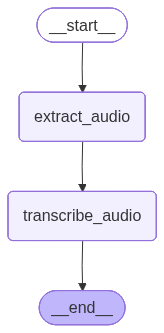

In [15]:
graph_builder=  StateGraph(State)
graph_builder.add_node("extract_audio",extract_audio)
graph_builder.add_node("transcribe_audio",transcribe_audio)

graph_builder.add_edge(START,"extract_audio")
graph_builder.add_edge("extract_audio","transcribe_audio")
graph_builder.add_edge("transcribe_audio",END)

graph = graph_builder.compile()
graph



In [16]:
graph.invoke({"video_file":"muscleUp.mp4"})


FileNotFoundError: [WinError 2] 지정된 파일을 찾을 수 없습니다